In [1]:
# ============================================================
# Notebook 03 — ARIMA Modelling
# Baseline V1: Manual order (1,1,1) — all four series
# Reference: Box & Jenkins (1970)
# Implementation: statsmodels (Seabold & Perktold, 2010)
# Author: Nihaar Raut | 001309432
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all four series
ndvi_amazon_train = pd.read_csv(PROCESSED / 'ndvi_amazon_train.csv', parse_dates=['date'])
ndvi_amazon_test = pd.read_csv(PROCESSED / 'ndvi_amazon_test.csv', parse_dates=['date'])

ndvi_sahel_train = pd.read_csv(PROCESSED / 'ndvi_sahel_train.csv', parse_dates=['date'])
ndvi_sahel_test = pd.read_csv(PROCESSED / 'ndvi_sahel_test.csv', parse_dates=['date'])

sst_atlantic_train = pd.read_csv(PROCESSED / 'sst_atlantic_train.csv', parse_dates=['date'])
sst_atlantic_test = pd.read_csv(PROCESSED / 'sst_atlantic_test.csv', parse_dates=['date'])

sst_indian_train = pd.read_csv(PROCESSED / 'sst_indian_train.csv', parse_dates=['date'])
sst_indian_test = pd.read_csv(PROCESSED / 'sst_indian_test.csv', parse_dates=['date'])

print("All series loaded successfully")
print(f"Train observations per series: ~252")
print(f"Test observations per series: 48")

All series loaded successfully
Train observations per series: ~252
Test observations per series: 48


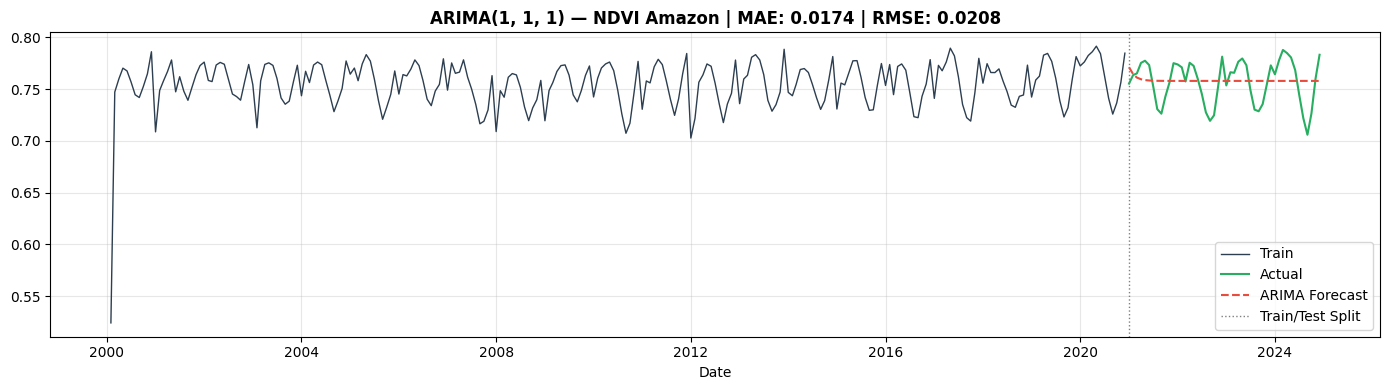

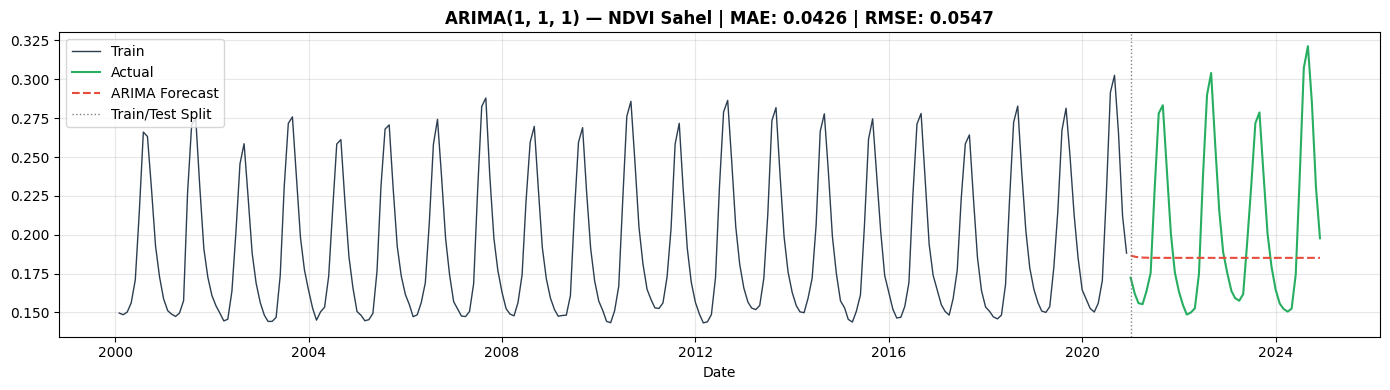

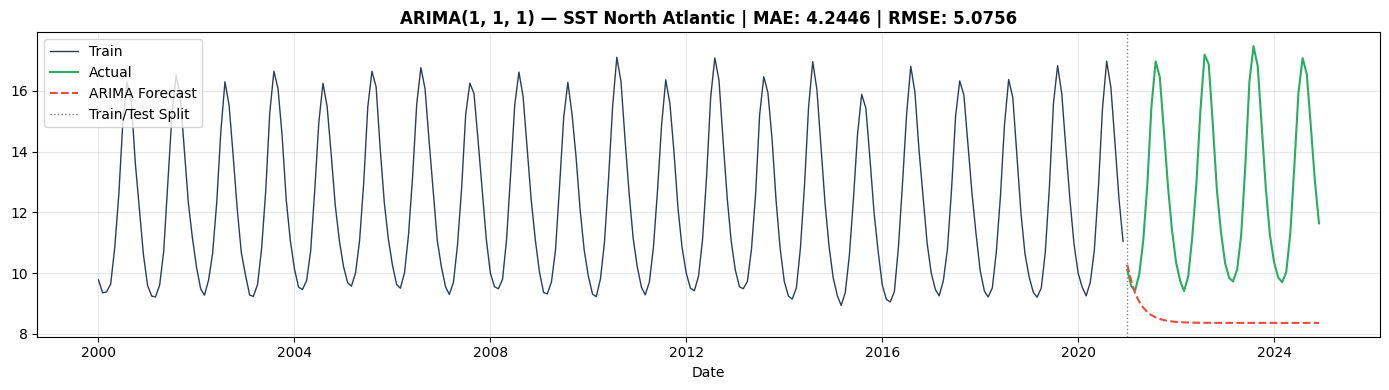

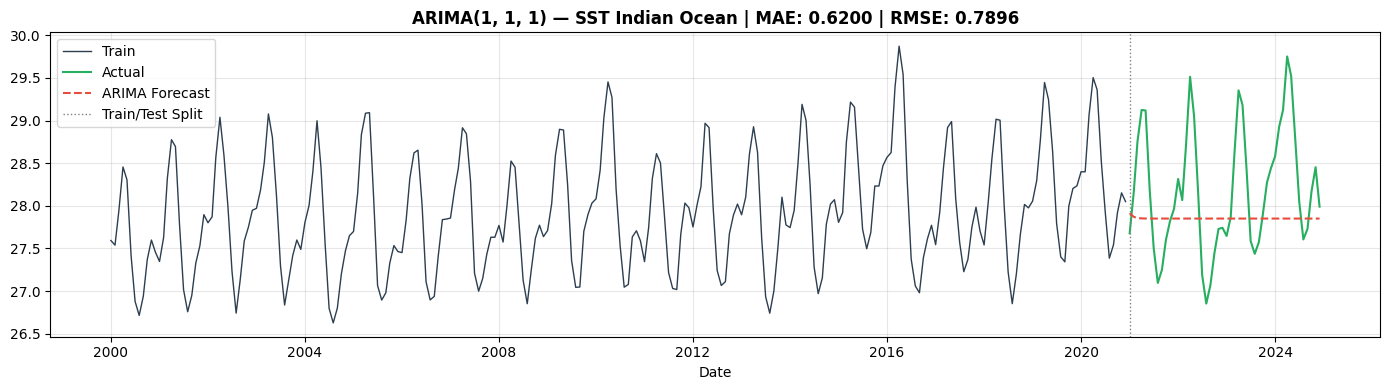


=== ARIMA V1 Baseline Results ===
            series     order    MAE   RMSE
       NDVI Amazon (1, 1, 1) 0.0174 0.0208
        NDVI Sahel (1, 1, 1) 0.0426 0.0547
SST North Atlantic (1, 1, 1) 4.2446 5.0756
  SST Indian Ocean (1, 1, 1) 0.6200 0.7896


In [2]:
# ============================================================
# ARIMA V1 — Baseline (1,1,1) all four series
# Order selected manually as starting point
# d=1 justified by ADF non-stationarity results
# ============================================================

def run_arima(train, test, value_col, series_name, order=(1,1,1)):
    # Fit model
    model = ARIMA(train[value_col], order=order)
    fitted = model.fit()
    
    # Forecast
    forecast = fitted.forecast(steps=len(test))
    actual = test[value_col].values
    
    # Metrics
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col], 
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual, 
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast, 
            color='#e74c3c', linewidth=1.5, linestyle='--', label='ARIMA Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey', 
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'ARIMA{order} — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}', 
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_arima_v1_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'series': series_name, 'order': order, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run V1 on all four series
results = []

results.append(run_arima(ndvi_amazon_train, ndvi_amazon_test, 
                          'ndvi_mean', 'NDVI Amazon'))

results.append(run_arima(ndvi_sahel_train, ndvi_sahel_test, 
                          'ndvi_mean', 'NDVI Sahel'))

results.append(run_arima(sst_atlantic_train, sst_atlantic_test, 
                          'sst_mean', 'SST North Atlantic'))

results.append(run_arima(sst_indian_train, sst_indian_test, 
                          'sst_mean', 'SST Indian Ocean'))

# Results table
results_df = pd.DataFrame(results)
print("\n=== ARIMA V1 Baseline Results ===")
print(results_df.to_string(index=False))

NDVI Amazon: best order = (3, 0, 0) | AIC = -1211.86


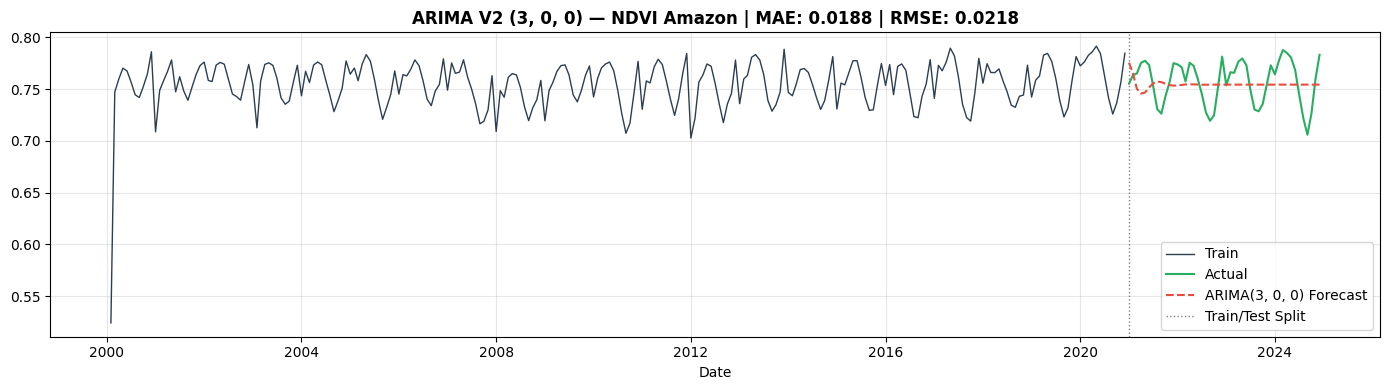

NDVI Sahel: best order = (2, 1, 2) | AIC = -1447.97


c:\Users\NIHAAR\Desktop\fyp-environmental-forecasting\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


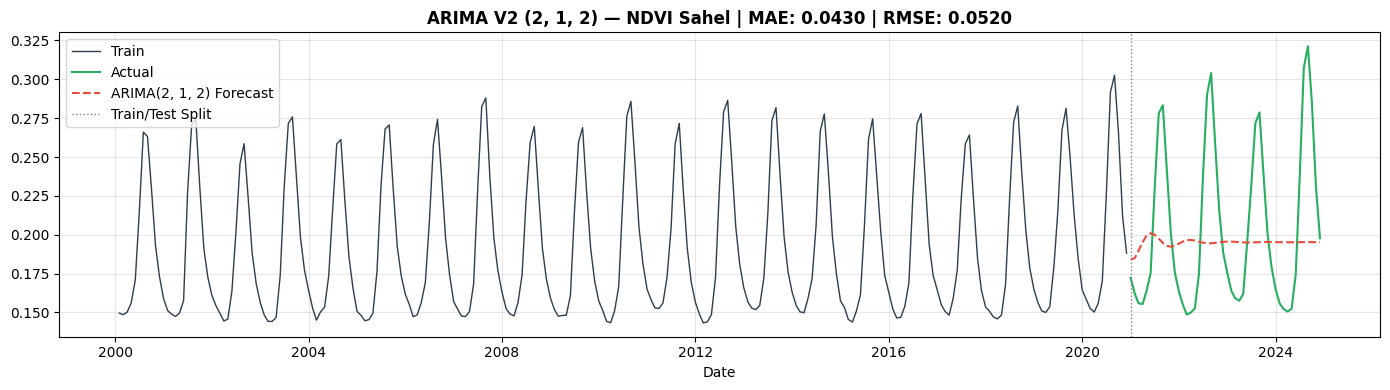

SST North Atlantic: best order = (2, 1, 0) | AIC = 370.90


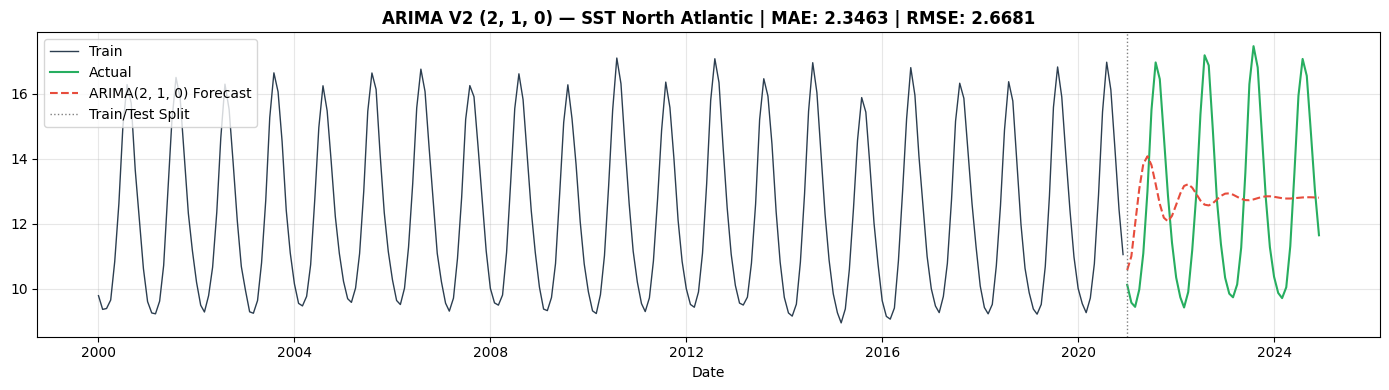

SST Indian Ocean: best order = (3, 0, 3) | AIC = 29.88


c:\Users\NIHAAR\Desktop\fyp-environmental-forecasting\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


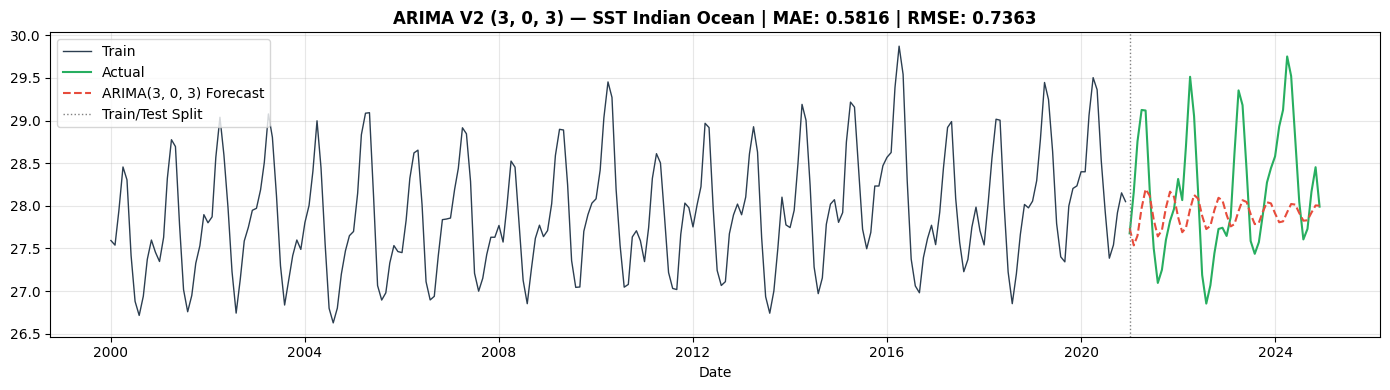


=== ARIMA V2 Results ===
            series     order    MAE   RMSE
       NDVI Amazon (3, 0, 0) 0.0188 0.0218
        NDVI Sahel (2, 1, 2) 0.0430 0.0520
SST North Atlantic (2, 1, 0) 2.3463 2.6681
  SST Indian Ocean (3, 0, 3) 0.5816 0.7363


In [3]:
# ============================================================
# ARIMA V2 — AIC-based automatic order selection (pmdarima)
# Replaces manual (1,1,1) with data-driven optimal (p,d,q)
# d informed by ADF results: CO2=1, Sahel=1, Atlantic=1, rest=0
# ============================================================

from pmdarima import auto_arima

def run_arima_v2(train, test, value_col, series_name, d=1):
    # Auto select best order by AIC
    auto = auto_arima(
        train[value_col],
        d=d,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        information_criterion='aic'
    )
    
    best_order = auto.order
    print(f"{series_name}: best order = {best_order} | AIC = {auto.aic():.2f}")
    
    # Fit and forecast
    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(train[value_col], order=best_order)
    fitted = model.fit()
    forecast = fitted.forecast(steps=len(test))
    actual = test[value_col].values
    
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast,
            color='#e74c3c', linewidth=1.5, linestyle='--', label=f'ARIMA{best_order} Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'ARIMA V2 {best_order} — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_arima_v2_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'series': series_name, 'order': str(best_order),
            'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run V2 — d values informed by ADF results
results_v2 = []

results_v2.append(run_arima_v2(ndvi_amazon_train, ndvi_amazon_test,
                                'ndvi_mean', 'NDVI Amazon', d=0))

results_v2.append(run_arima_v2(ndvi_sahel_train, ndvi_sahel_test,
                                'ndvi_mean', 'NDVI Sahel', d=1))

results_v2.append(run_arima_v2(sst_atlantic_train, sst_atlantic_test,
                                'sst_mean', 'SST North Atlantic', d=1))

results_v2.append(run_arima_v2(sst_indian_train, sst_indian_test,
                                'sst_mean', 'SST Indian Ocean', d=0))

results_v2_df = pd.DataFrame(results_v2)
print("\n=== ARIMA V2 Results ===")
print(results_v2_df.to_string(index=False))
